In [50]:
import os
import librosa
import numpy
import pandas
import glob
import torch


from pathlib import Path

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,TensorDataset


from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder

import torch.nn.functional as F

import seaborn as sns

In [ ]:
#hyper parameters

epochs = 100
batch_size = 20
learning_rate = 0.001
beta = 4
latent_dim=64

genre_embed_dim = 16

In [3]:
#dataset directory

current_dir = Path().resolve()
base_dir= Path().resolve().parent
DATASET_PATH_jazz_song = base_dir/ "data" / "medium_task_dataset"/"songs"/"jazz_song"
DATASET_PATH_pop_song = base_dir/ "data" / "medium_task_dataset"/"songs"/"pop_song"

In [4]:
#dataset song

dataset_song=[]

dataset_jazz_song = os.listdir(DATASET_PATH_jazz_song)
dataset_pop_song = os.listdir(DATASET_PATH_pop_song)

dataset_song = dataset_jazz_song + dataset_pop_song

print(dataset_song)

['Amy Winehouse - Love Is A Losing Game.mp3', 'Astrud Gilberto and Stan Getz - The Girl From Ipanema.mp3', 'Billie Holiday - Strange Fruit.mp3', 'Fly Me To The Moon.mp3', 'Grover Washington Jr. - Just the Two of Us.mp3', 'L-O-V-E.mp3', 'Laufey - From The Start.mp3', 'Louis Armstrong - What A Wonderful World.mp3', 'Lovefool - Vintage Jazz Cardigans.mp3', "Norah Jones - Don't Know Why.mp3", 'Parov Stelar - All Night.mp3', 'Royals - (Sad Clown With The Golden Voice).mp3', 'Sade - Smooth Operator.mp3', 'The Girl From Ipanema - Frank Sinatra & Antônio Carlos Jobim.mp3', 'Theme From New York, New York.mp3', 'Adele - Rolling in the Deep.mp3', 'Dua Lipa - Levitating.mp3', 'Dua Lipa - New Rules.mp3', 'Ed Sheeran - Shape of You.mp3', 'Fifth Harmony - Work from Home.mp3', 'Justin Bieber - Baby.mp3', 'Justin Bieber - Let Me Love You.mp3', "Justin Timberlake - CAN'T STOP THE FEELING.mp3", 'Mark Ronson - Uptown Funk.mp3', 'Miley Cyrus - Flowers.mp3', 'Sabrina Carpenter - Espresso.mp3', 'Sabrina Carp

In [5]:
#metadata csv file creation

rows=[]

#song directories
DATASET_PATH_jazz_song = base_dir/ "data" / "hard_task_dataset"/"songs"/"jazz_song"
DATASET_PATH_pop_song = base_dir/ "data" / "hard_task_dataset"/"songs"/"pop_song"
hard_task_dataset_path = base_dir/ "data" / "hard_task_dataset" 

#lyrics directories

DATASET_PATH_jazz_lyrics = base_dir/ "data" / "hard_task_dataset"/"lyrics"/"jazz_lyrics"
DATASET_PATH_pop_lyrics = base_dir/ "data" / "hard_task_dataset"/"lyrics"/"pop_lyrics"


for file in os.listdir(DATASET_PATH_jazz_song):

      # song1.mp3 -> song1
    song_id = os.path.splitext(file)[0]
    audio_path = os.path.join(DATASET_PATH_jazz_song,  file)

    # song1.mp3 -> song1.txt
    lyrics_file = file.replace(".mp3", ".txt")
    lyrics_path = os.path.join(DATASET_PATH_jazz_lyrics,lyrics_file)

    rows.append({
            "song_id": song_id,
            "audio_path": audio_path.replace("\\", "/"),
            "lyrics_path": lyrics_path.replace("\\", "/") if lyrics_path else "",
            "genre":"jazz"
        })
    
for file in os.listdir(DATASET_PATH_pop_song):
    
    song_id = os.path.splitext(file)[0]
    audio_path = os.path.join(DATASET_PATH_pop_song,  file)

    lyrics_file = file.replace(".mp3", ".txt")
    lyrics_path = os.path.join(DATASET_PATH_pop_lyrics,lyrics_file)

    rows.append({
            "song_id": song_id,
            "audio_path": audio_path.replace("\\", "/"),
            "lyrics_path": lyrics_path.replace("\\", "/") if lyrics_path else "",
            "genre":"pop"
        })    

df = pandas.DataFrame(rows)

df.to_csv(os.path.join(hard_task_dataset_path, "metadata.csv"), index=False)

print("Metadata created with", len(df), "songs")
# print(df.head())



Metadata created with 30 songs


In [6]:
#extract mel spectrogram

melspectrogram=[]

for data in dataset_jazz_song:
    song_path = os.path.join(DATASET_PATH_jazz_song,data)
    y,sr = librosa.load(song_path,duration=30)
    melspectrogram.append(librosa.feature.melspectrogram(y=y,sr=sr,n_mels=128))

for data in dataset_pop_song:
    song_path = os.path.join(DATASET_PATH_pop_song,data)
    y,sr = librosa.load(song_path,duration=30)
    melspectrogram.append(librosa.feature.melspectrogram(y=y,sr=sr,n_mels=128))    

# print('melspectrogram',melspectrogram)

# Convert to log scale 
mel_db=librosa.power_to_db(melspectrogram,ref=numpy.max)

print(mel_db.shape)



#Normalize
mel_db = (mel_db - numpy.mean(mel_db)) / numpy.std(mel_db)
for i in mel_db:
    print(i.shape)
print(mel_db.shape)

(30, 128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(30, 128, 1292)


In [7]:
#train dataset_song

#numpy array to tensor
dataset_tensor=torch.tensor(mel_db, dtype=torch.float32).unsqueeze(1)
print(dataset_tensor.shape)
dataset = TensorDataset(dataset_tensor)
train_dataset_song=DataLoader(dataset = dataset,
                         batch_size = batch_size,
                         shuffle=True)

print(train_dataset_song)
# for batch in train_dataset_song:
#     print(batch)
#     break

torch.Size([30, 1, 128, 1292])


In [12]:
latent_dim=64

class Beta_VAE(nn.Module):
    def __init__(self,latent_dim=latent_dim):
        super().__init__()
        
        #encoder
        #4 convolutional layer
        self.encode= nn.Sequential(
            
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.ReLU(),
          
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.ReLU(),

  
      
            
            nn.AdaptiveAvgPool2d((4, 4))
             
        )  

  
        self.flatten = nn.Flatten()



        self.mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.logvar = nn.Linear(256 * 4 * 4, latent_dim)


        self.fc_decode = nn.Linear(latent_dim, 256 * 4 * 4)

        #decoder
        # 4 deconvolutional layer
        self.decode=nn.Sequential(
            nn.ConvTranspose2d(in_channels = 256,out_channels = 128,kernel_size= 4,stride= 2,padding= 1),
          
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            
            nn.Sigmoid(),
        ) 
    def encoder(self,x):
    
        x = self.encode(x)
        x = x.view(x.size(0), -1)
        x = self.flatten(x)
        mu = self.mu(x)
        logvar = self.logvar(x)
   
        return mu, logvar 
     
     #z=mu + epsilon*standard deviation
    def reparameterization(self,mu,logvar):
        standard_deviation = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(standard_deviation)
        return mu + epsilon * standard_deviation

    # def decoder(self,z):
      
    #         x = self.fc_decode(z)
    #         x = x.view(-1, 256, 4, 4)
    #         x = self.decode(x)
    #         return x

    def decoder(self, z):
        x = self.fc_decode(z)         

        # print("BEFORE RESHAPE:", x.shape) 
        x = x.view(x.size(0), 256, 4, 4)   
        # print("AFTER RESHAPE:", x.shape)   
        x = self.decode(x)                

         #FORCE CORRECT SHAPE
        x = F.interpolate(x, size=(128, 1292), mode="bilinear", align_corners=False)

        return x

    def forward(self,x):
        mu, logvar = self.encoder(x)
        z = self.reparameterization(mu, logvar)
        reconstructed_x = self.decoder(z)
        return reconstructed_x, mu, logvar, z  
     






In [ ]:
#vae loss function
def beta_vae_loss(reconstructed_x,x,mu,logvar):
    reconstruction_loss=nn.functional.mse_loss(reconstructed_x,x)
    kl=0.5 * torch.sum(mu.pow(2) + logvar.exp() - 1 - logvar )


    # beta = 4  # disentanglement strength
    loss = reconstruction_loss + beta * kl

    return loss

In [14]:
#device
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [15]:
model=Beta_VAE()  #creating object of class cnn_vae
optimizer=optim.Adam(model.parameters(),lr=1e-3)

In [16]:
#model training

model.train()

for epoch in range(epochs):
    total_loss=0

    for (x,) in (train_dataset_song):
        
        x = x.to(device)
      
        optimizer.zero_grad()

        x_reconstructed,mu,logvar,z = model(x)  # x_reconstructed, mu, logvar = model.forward(x)
        loss=vae_loss( x_reconstructed,x,mu,logvar)

        loss.backward()
        optimizer.step()

        total_loss=total_loss + loss.item()

    avg_loss=total_loss/len(train_dataset_song.dataset)   


    print(f"epoch [{epoch+1}/{epochs},loss:{avg_loss:.4f}]")

epoch [1/100,loss:0.4237]
epoch [2/100,loss:0.0981]
epoch [3/100,loss:0.0907]
epoch [4/100,loss:0.0817]
epoch [5/100,loss:0.0767]
epoch [6/100,loss:0.0705]
epoch [7/100,loss:0.0696]
epoch [8/100,loss:0.0670]
epoch [9/100,loss:0.0665]
epoch [10/100,loss:0.0659]
epoch [11/100,loss:0.0654]
epoch [12/100,loss:0.0643]
epoch [13/100,loss:0.0611]
epoch [14/100,loss:0.0636]
epoch [15/100,loss:0.0631]
epoch [16/100,loss:0.0614]
epoch [17/100,loss:0.0617]
epoch [18/100,loss:0.0614]
epoch [19/100,loss:0.0605]
epoch [20/100,loss:0.0586]
epoch [21/100,loss:0.0561]
epoch [22/100,loss:0.0591]
epoch [23/100,loss:0.0587]
epoch [24/100,loss:0.0593]
epoch [25/100,loss:0.0579]
epoch [26/100,loss:0.0589]
epoch [27/100,loss:0.0576]
epoch [28/100,loss:0.0588]
epoch [29/100,loss:0.0582]
epoch [30/100,loss:0.0579]
epoch [31/100,loss:0.0584]
epoch [32/100,loss:0.0584]
epoch [33/100,loss:0.0571]
epoch [34/100,loss:0.0563]
epoch [35/100,loss:0.0580]
epoch [36/100,loss:0.0573]
epoch [37/100,loss:0.0574]
epoch [38/

In [17]:
#extract latent features

model.eval()

latent_features=[]
with torch.no_grad():
     for (x,) in (train_dataset_song):
          x=x.to(device)
          x_reconstructed,mu,logvar,z=model(x)
          latent_features.append(mu.cpu().numpy())
          
print(latent_features)
latent_representation = numpy.vstack(latent_features)    
print(latent_representation)

[array([[ 4.5380060e-05,  1.9479961e-05, -9.2274815e-05, ...,
        -3.6183766e-05,  3.8386039e-05,  1.6089984e-05],
       [-7.9714082e-05, -9.0192378e-05,  3.5961282e-05, ...,
        -2.7145608e-05,  9.6129806e-05, -7.6620177e-05],
       [ 7.9418671e-05, -2.4402372e-05,  3.5556623e-05, ...,
        -1.3256934e-04, -7.0500551e-05,  4.8360307e-06],
       ...,
       [-4.0851082e-06, -5.8728619e-06, -8.7449334e-05, ...,
        -1.9924642e-05,  5.9659058e-05,  3.9263217e-05],
       [-1.9831976e-05,  1.2421646e-05, -1.0709658e-04, ...,
         1.1225966e-05,  5.3879656e-05, -6.6250854e-05],
       [ 1.2485310e-04, -7.7644596e-05, -1.0272830e-04, ...,
        -2.2407970e-05,  9.4320625e-05, -1.6394188e-04]],
      shape=(20, 64), dtype=float32), array([[ 5.72921563e-05, -2.01066323e-05, -1.13446571e-04,
         1.11225738e-04,  8.89271323e-05,  5.01855466e-05,
        -4.13128619e-05,  1.07821885e-04,  1.83636985e-05,
        -1.75480454e-05, -9.81441408e-05, -1.72045256e-04,
    

In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2)
labels_kmeans = kmeans.fit_predict(latent_representation)

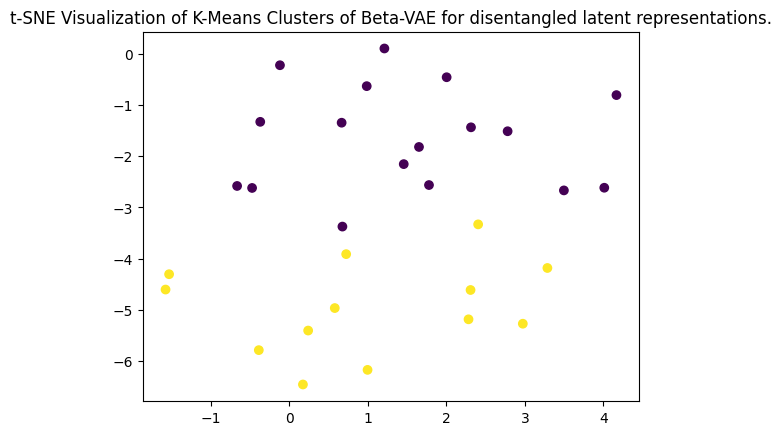

In [22]:
#visualization
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=15, random_state=42)
X_2d = tsne.fit_transform(latent_representation)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_kmeans, cmap='viridis')
plt.title("t-SNE Visualization of K-Means Clusters of Beta-VAE for disentangled latent representations.")
plt.show()

In [23]:
# pretrained SentenceTransformer model
# 'all-MiniLM-L6-v2' outputs 384-dimensional embeddings
sentence_transformer_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9942.54it/s]


In [62]:
# hybrid feature fusion (lyrics + audio)

def lyrics_embeddings(lyrics_path):
    with open(lyrics_path, "r", encoding="utf-8") as f:
         lyrics_text = f.read().strip()

         embedding =  sentence_transformer_model.encode(
                                    lyrics_text,
                                    convert_to_numpy=True,
                                    normalize_embeddings=True  
                                
         )
                               

    return embedding

def audio_latent_features(song_path):
    y, sr = librosa.load(song_path, duration=30)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel, ref=numpy.max)

    # Normalize (keep 2D structure)
    mel_db = (mel_db - numpy.mean(mel_db)) / (numpy.std(mel_db) + 1e-6)

       # FIX: pad or crop time dimension
    target_time = 128

    if mel_db.shape[1] < target_time:
        pad_width = target_time - mel.shape[1]
        mel = numpy.pad(mel, ((0,0),(0,pad_width)))

    else:
        mel = mel[:, :target_time]

    # Convert to tensor (KEEP 2D!)
    data_tensor = torch.tensor(mel_db, dtype=torch.float32)

    # CNN format: (batch=1, channel=1, height=128, width=time)
    data_tensor = data_tensor.unsqueeze(0).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        x = data_tensor.to(device)
        x_reconstructed, mu, logvar, z = model(x)
        latent_features = mu.squeeze(0).cpu().numpy()

    return latent_features
  
  

df = pandas.read_csv(base_dir/ "data" / "hard_task_dataset"/ "metadata.csv")

label_encoder = LabelEncoder()
df["genre_id"] = label_encoder.fit_transform(df["genre"])

# Number of unique genres
num_genres = df["genre_id"].nunique()
genre_embedding = nn.Embedding(num_genres, genre_embed_dim)



hybrid_features = []

for index,row in df.iterrows():

    audio_vec = audio_latent_features(row["audio_path"])
    lyrics_vec = lyrics_embeddings(row["lyrics_path"])

      # Genre ID (already encoded)
    genre_id = torch.tensor([row["genre_id"]], dtype=torch.long)

    # Genre embedding → tensor shape (1, genre_embed_dim)
    with torch.no_grad():
        genre_vec = genre_embedding(genre_id)
    
    

    # Convert both to 1D numpy arrays
    audio_vec = numpy.asarray(audio_vec).flatten()
    lyrics_vec = numpy.asarray(lyrics_vec).flatten()
    genre_vec =  numpy.asarray(genre_vec).flatten()




    print(audio_vec.shape, lyrics_vec.shape,genre_vec.shape)  

    hybrid_vec = numpy.concatenate([audio_vec, lyrics_vec,genre_vec])

    hybrid_features.append(hybrid_vec)

# hybrid_features = numpy.array(hybrid_features)
hybrid_features = numpy.vstack(hybrid_features)
print(hybrid_features.shape)


(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(64,) (384,) (16,)
(30, 464)


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(hybrid_features)

In [ ]:
#k-means clustering algorithm
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(hybrid_features)
print(labels_kmeans)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


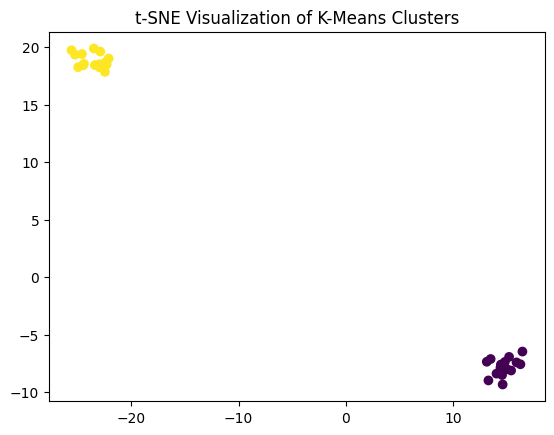

In [34]:
#visualization
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=10, random_state=42)
X_2d = tsne.fit_transform(hybrid_features)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_kmeans, cmap='viridis')
plt.title("t-SNE Visualization of K-Means Clusters")
plt.show()

In [ ]:
# Evaluation Metrics

In [35]:
# Silhouette Score
from sklearn.metrics import silhouette_score

score = silhouette_score(hybrid_features, labels_kmeans)
print("Silhouette Score:", score)

Silhouette Score: 0.9998496770858765


In [40]:
# Normalized Mutual Information (NMI)
from sklearn.metrics import normalized_mutual_info_score

le = LabelEncoder()
true_genre = le.fit_transform(df["genre"]) 

nmi = normalized_mutual_info_score(true_genre, labels_kmeans)
print("NMI:", nmi)

NMI: 1.0


In [41]:
# Adjusted Rand Index (ARI)
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(true_genre, labels_kmeans)
print("ARI:", ari)

ARI: 1.0


In [42]:
# Cluster Purity
import numpy as np
from scipy.stats import mode

def purity_score(y_true, y_pred):
    clusters = np.unique(y_pred)
    total_correct = 0

    for c in clusters:
        idx = np.where(y_pred == c)[0]
        most_common = mode(y_true[idx], keepdims=True).mode[0]
        total_correct += np.sum(y_true[idx] == most_common)

    return total_correct / len(y_true)

purity = purity_score(true_genre, labels_kmeans)
print("Purity:", purity)

Purity: 1.0


(30, 64)


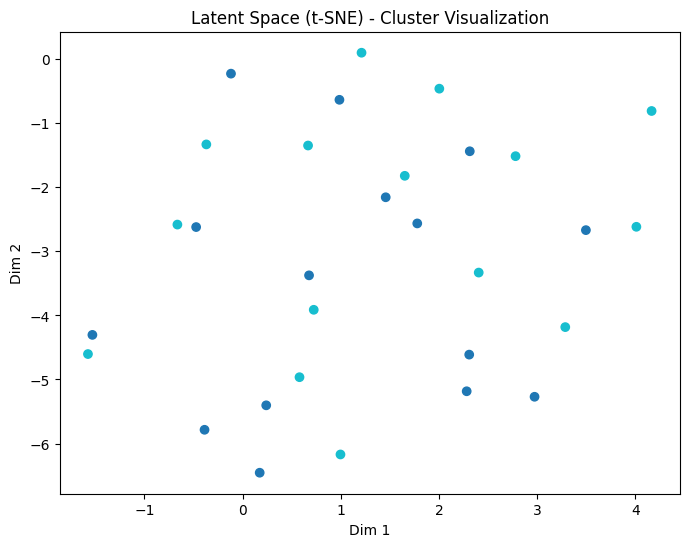

In [47]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt



latent_features = np.vstack(latent_features)
print(latent_features.shape)

# latent_features = output from VAE encoder (mu)
z_2d = TSNE(n_components=2, perplexity=15, random_state=42).fit_transform(latent_features)

plt.figure(figsize=(8,6))
plt.scatter(z_2d[:, 0], z_2d[:, 1], c=labels_kmeans, cmap='tab10')
plt.title("Latent Space of Beta VAE(t-SNE) - Cluster Visualization")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()



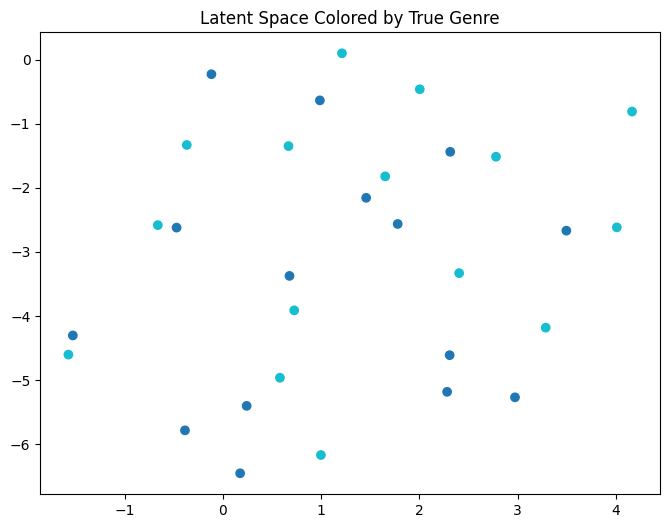

In [48]:
plt.figure(figsize=(8,6))
plt.scatter(z_2d[:, 0], z_2d[:, 1], c=true_genre, cmap='tab10')
plt.title("Latent Space Colored by True Genre")
plt.show()

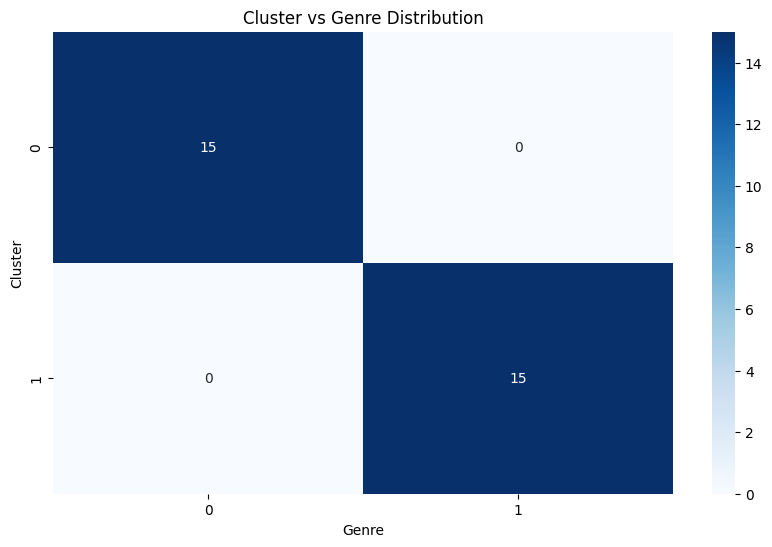

In [51]:

#confusion matrix

df_vis = pandas.DataFrame({
    "cluster": labels_kmeans,
    "genre": true_genre
})

ct = pandas.crosstab(df_vis["cluster"], df_vis["genre"])

plt.figure(figsize=(10,6))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("Cluster vs Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Cluster")
plt.show()

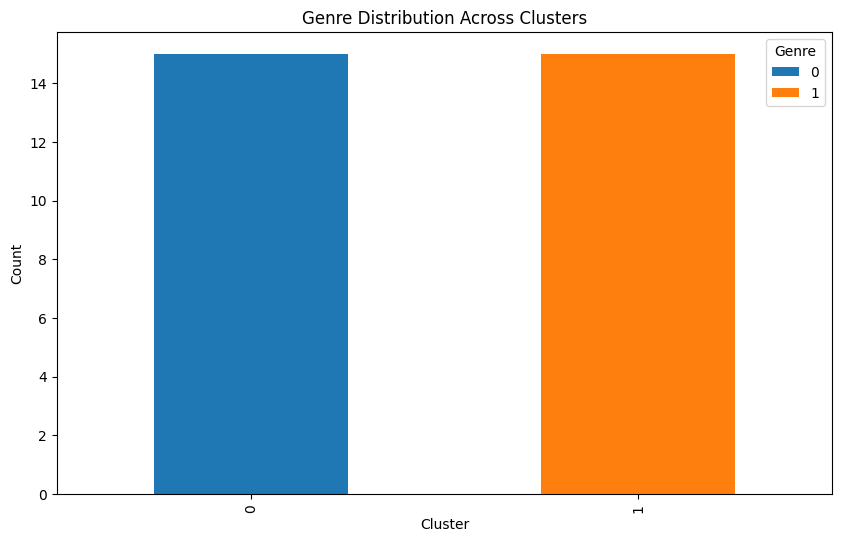

In [52]:
# Genre distribution per cluster
ct.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Genre Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.legend(title="Genre")
plt.show()

In [70]:
def get_audio_tensor(path):
    y, sr = librosa.load(path, duration=30)

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel = librosa.power_to_db(mel)

    mel = (mel - mel.mean()) / (mel.std() + 1e-6)

    target = 128
    if mel.shape[1] < target:
        mel = np.pad(mel, ((0,0),(0,target-mel.shape[1])))
    else:
        mel = mel[:, :target]

    x = torch.tensor(mel, dtype=torch.float32)

    return x.unsqueeze(0).unsqueeze(0)  # (1,1,128,128)

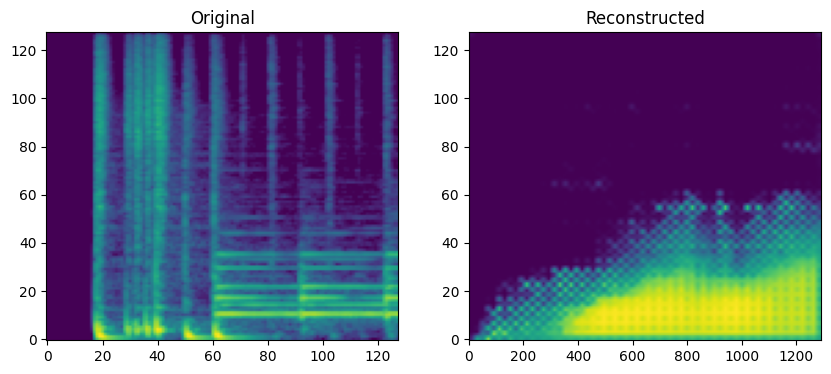

In [78]:
import matplotlib.pyplot as plt

model.eval()

# latent_features= audio_latent_features(audio_path)


for _, row in df.iterrows():
    audio_path = row["audio_path"]



    x_sample = get_audio_tensor(audio_path)
    x_sample = x_sample.to(device)


with torch.no_grad():
   
        x_recon, mu, logvar, z = model(x_sample)
   
# orig = x_sample[0].cpu().numpy()
# recon = x_recon[0].cpu().numpy()

orig = x_sample[0].cpu().numpy().squeeze()
recon = x_recon[0].cpu().numpy().squeeze()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(orig, aspect='auto', origin='lower')

plt.subplot(1,2,2)
plt.title("Reconstructed")
plt.imshow(recon, aspect='auto', origin='lower')

plt.show()

In [ ]:
#K-Means and direct spectral feature clustering.

In [94]:
#k-means clustering algorithm
from sklearn.cluster import KMeans

# reshape
mel_db_flat = mel_db.reshape(mel_db.shape[0], -1)
print(mel_db_flat)

# scale
scaler = StandardScaler()
X = scaler.fit_transform(mel_db_flat)

# clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X)

print(labels_kmeans)



[[-1.4698852  -1.4698852  -1.4698852  ... -1.4698852  -1.4698852
  -1.4698852 ]
 [-1.4698852  -1.4698852  -1.4698852  ... -1.4698852  -1.4698852
  -1.4698852 ]
 [-1.4698852  -1.4698852  -1.4698852  ... -1.4698852  -1.4698852
  -1.4698852 ]
 ...
 [-1.4698852  -1.4698852  -1.4698852  ... -1.4698852  -1.4698852
  -1.4698852 ]
 [-1.4698852  -1.4698852  -1.4698852  ... -0.457066   -0.4377448
  -0.55586624]
 [-1.4698852  -1.4698852  -1.4698852  ... -0.49326482 -0.4637673
  -0.37695318]]
[1 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 1 1 1 1 0 0 1 1 0 0 1 0 1]


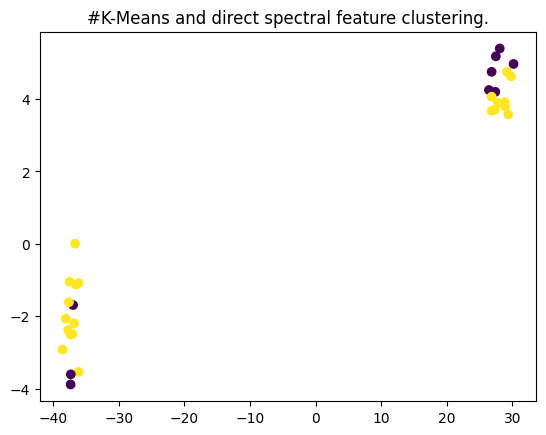

In [96]:
#visualization
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=10, random_state=42)
X_2d = tsne.fit_transform(hybrid_features)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_kmeans, cmap='viridis')
plt.title("#K-Means and direct spectral feature clustering.")
plt.show()

In [ ]:
#pca + kmeans

In [98]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)   # you can tune this (20–100 common)
X_pca = pca.fit_transform(hybrid_features)

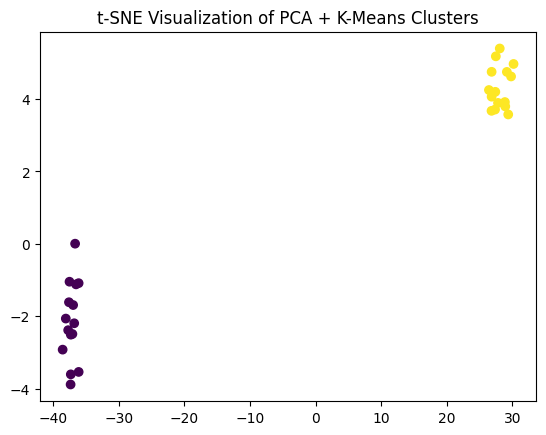

In [100]:
# KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)


tsne = TSNE(n_components=2, perplexity=10, random_state=42)
X_2d = tsne.fit_transform(hybrid_features)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis')
plt.title("t-SNE Visualization of PCA + K-Means Clusters")
plt.show()


In [ ]:
#autoencoder

In [79]:
import torch
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=64):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

In [ ]:
model = Autoencoder(input_dim=464, latent_dim=64)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


model.train()
epochs = 50

for epoch in range(epochs):
   
    total_loss=0

    for (x,) in (train_dataset_song):

        optimizer.zero_grad()

        x_recon, z = model(X)

        loss = criterion(x_recon, X)

        loss.backward()
        optimizer.step()
    
    avg_loss=total_loss/len(train_dataset_song.dataset) 
  
    print(f"epoch [{epoch+1}/{epochs},loss:{avg_loss:.4f}]")

epoch [1/50,loss:0.0000]
epoch [2/50,loss:0.0000]
epoch [3/50,loss:0.0000]
epoch [4/50,loss:0.0000]
epoch [5/50,loss:0.0000]
epoch [6/50,loss:0.0000]
epoch [7/50,loss:0.0000]
epoch [8/50,loss:0.0000]
epoch [9/50,loss:0.0000]
epoch [10/50,loss:0.0000]
epoch [11/50,loss:0.0000]
epoch [12/50,loss:0.0000]
epoch [13/50,loss:0.0000]
epoch [14/50,loss:0.0000]
epoch [15/50,loss:0.0000]
epoch [16/50,loss:0.0000]
epoch [17/50,loss:0.0000]
epoch [18/50,loss:0.0000]
epoch [19/50,loss:0.0000]
epoch [20/50,loss:0.0000]
epoch [21/50,loss:0.0000]
epoch [22/50,loss:0.0000]
epoch [23/50,loss:0.0000]
epoch [24/50,loss:0.0000]
epoch [25/50,loss:0.0000]
epoch [26/50,loss:0.0000]
epoch [27/50,loss:0.0000]
epoch [28/50,loss:0.0000]
epoch [29/50,loss:0.0000]
epoch [30/50,loss:0.0000]
epoch [31/50,loss:0.0000]
epoch [32/50,loss:0.0000]
epoch [33/50,loss:0.0000]
epoch [34/50,loss:0.0000]
epoch [35/50,loss:0.0000]
epoch [36/50,loss:0.0000]
epoch [37/50,loss:0.0000]
epoch [38/50,loss:0.0000]
epoch [39/50,loss:0.0

In [88]:
model.eval()

with torch.no_grad():
    _, latent_features = model(X)

latent_features = latent_features.numpy()
print(latent_features.shape)

(30, 64)


In [89]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
pred_labels = kmeans.fit_predict(latent_features)
pred_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

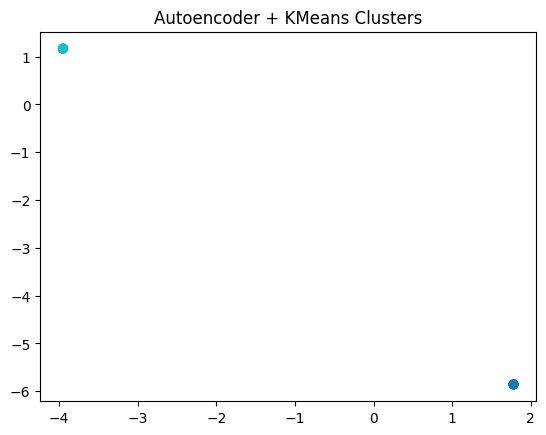

In [90]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

z_2d = TSNE(n_components=2, perplexity=15, random_state=42).fit_transform(latent_features)

plt.scatter(z_2d[:,0], z_2d[:,1], c=pred_labels, cmap="tab10")
plt.title("Autoencoder + KMeans Clusters")
plt.show()